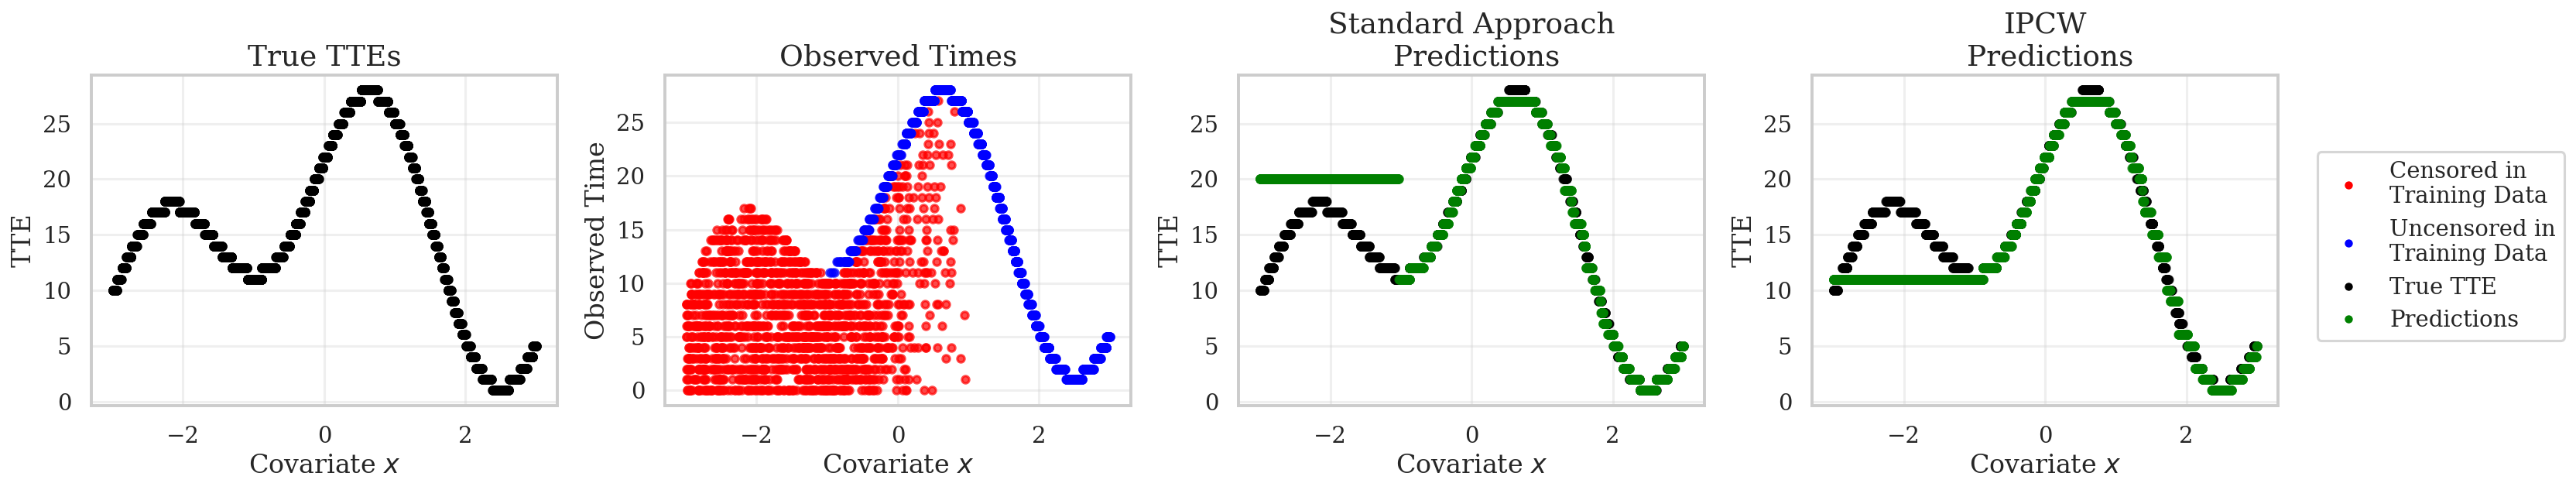

In [74]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.lines import Line2D

sns.set(style="whitegrid")
sns.set_context("talk")
# Configure global plotting settings for a clean paper look
rcParams.update({
    "font.family": "serif",
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.dpi': 150,
    'axes.grid': True,
    'grid.alpha': 0.3
})

all_models = ['dhcind', 'icind']
all_models_names = ['Standard Approach\n', 'IPCW\n']

for COUNT in [900]:
    suffix = f'COUNT{COUNT}'
    X_test = joblib.load(f'/data4/meerak/onevar_data/X_test_{suffix}.joblib').reshape(-1, 1)
    y_test = joblib.load(f'/data4/meerak/onevar_data/y_test_{suffix}.joblib')
    binary_y_test = joblib.load(f'/data4/meerak/onevar_data/actual_binary_y_test{suffix}.joblib')

    X_train = joblib.load(f'/data4/meerak/onevar_data/X_train_{suffix}.joblib').reshape(-1, 1)
    orig_y_train = joblib.load(f'/data4/meerak/onevar_data/orig_y_train_{suffix}.joblib')
    y_train = joblib.load(f'/data4/meerak/onevar_data/y_train_{suffix}.joblib')
    binary_y_train = joblib.load(f'/data4/meerak/onevar_data/binary_y_train_{suffix}.joblib')

    X_val = joblib.load(f'/data4/meerak/onevar_data/X_val_{suffix}.joblib').reshape(-1, 1)
    y_val = joblib.load(f'/data4/meerak/onevar_data/y_val_{suffix}.joblib')
    binary_y_val = joblib.load(f'/data4/meerak/onevar_data/binary_y_val_{suffix}.joblib')

    n_models = len(all_models)
    n_subplots = 2 + n_models
    n_cols = 4
    n_rows = (n_subplots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    axes = axes.flatten()

    # Plot 1: X_train vs orig_y_train
    axes[0].scatter(X_train, orig_y_train, color='black', s=20)
    axes[0].set_xlabel("Covariate $x$")
    axes[0].set_ylabel("TTE")
    axes[0].set_title("True TTEs")

    # Plot 2: X_train vs y_train split by censoring
    axes[1].scatter(X_train[binary_y_train == 0], y_train[binary_y_train == 0], label='Censored', alpha=0.7, color='red', s=20)
    axes[1].scatter(X_train[binary_y_train == 1], y_train[binary_y_train == 1], label='Uncensored', alpha=0.7, color='blue', s=20)
    axes[1].set_xlabel("Covariate $x$")
    axes[1].set_ylabel("Observed Time")
    axes[1].set_title("Observed Times")

    # Plot 3+: model predictions
    for i, (model, modelname) in enumerate(zip(all_models, all_models_names), start=2):
        preds = joblib.load(f'/data4/meerak/onevar_test_preds/{model}_y_test_pred_{suffix}.joblib')
        axes[i].scatter(X_test, y_test, label='True TTE', alpha=0.6, color='black', s=20)
        axes[i].scatter(X_test, preds, label='Predictions', alpha=0.6, color='green', s=20)
        axes[i].set_xlabel("Covariate $x$")
        axes[i].set_ylabel("TTE")
        axes[i].set_title(f"{modelname} Predictions")

    # Hide unused subplots
    for j in range(n_subplots, len(axes)):
        fig.delaxes(axes[j])
        
    # Collect legend handles and labels globally
    all_handles = []
    all_labels = []

    # Example: within your plotting loop
    # (for all subplots, don't call `.legend()` yet)

    # For the observed time plot:
    handle1 = Line2D([0], [0], marker='o', color='w', label='Censored',
                     markerfacecolor='red', markersize=6)
    handle2 = Line2D([0], [0], marker='o', color='w', label='Uncensored',
                     markerfacecolor='blue', markersize=6)
    all_handles.extend([handle1, handle2])
    all_labels.extend(['Censored in\nTraining Data', 'Uncensored in\nTraining Data'])

    # For model prediction plots:
    true_handle = Line2D([0], [0], marker='o', color='w', label='TTEs',
                     markerfacecolor='black', markersize=6)
    pred_handle = Line2D([0], [0], marker='o', color='w', label='Predictions',
                     markerfacecolor='green', markersize=6)
    all_handles.extend([true_handle, pred_handle])
    all_labels.extend(['True TTE', 'Predictions'])
    
    fig.legend(all_handles, all_labels,
           loc='upper left', bbox_to_anchor=(1, 0.7),
           ncol=1, frameon=True)


    plt.tight_layout()
    plt.savefig(f"onevar_preds_COUNT{COUNT}.png", bbox_inches='tight')
